# Forecasting Kunjungan Rawat Jalan dengan CRISP-DM

Notebook ini menyatukan proses pembangunan model Prophet per poliklinik dari pemahaman kebutuhan hingga penyimpanan artefak produksi. Seluruh tahapan mengikuti **CRISP-DM**: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment.

> **Privasi:** dataset mentah mengandung identitas pasien. Notebook tidak menampilkan baris mentah dan artefak yang disimpan hanya berisi agregat `ds`, `poli`, dan `y`.

## Persiapan lingkungan

Jalankan notebook dari root proyek atau folder `notebooks`. Dependensi dapat dipasang dengan `python -m pip install -r requirements-dev.txt`, lalu JupyterLab dibuka menggunakan `python -m jupyterlab`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'config.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'config.py').exists():
    raise RuntimeError('Root proyek tidak ditemukan. Buka notebook dari dalam repositori.')
sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

WindowsPath('D:/PROYEK/forecasting-jumlah-pasien')

In [2]:
import json
import logging
import platform
import re
from datetime import datetime
from zoneinfo import ZoneInfo

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import prophet
from prophet import Prophet
from IPython.display import Markdown, display

from config import (
    APP_TIMEZONE, DATE_COLUMN, EVALUATION_PREDICTIONS_PATH, METADATA_PATH,
    METRICS_PATH, MODELS_DIR, POLI_COLUMN, PROCESSED_DATA_PATH,
    PROPHET_CONFIG, PROPHET_TUNING_CANDIDATES, QUALITY_REPORT_PATH,
    RANDOM_SEED, RAW_DATA_PATH, TEST_HORIZON_DAYS,
)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
print(f'Python {platform.python_version()} | pandas {pd.__version__} | Prophet {prophet.__version__}')

C:\Users\Reymondo Saputra S\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python 3.12.10 | pandas 3.0.3 | Prophet 1.3.0


In [3]:
# Seluruh fungsi pembangunan model didefinisikan di notebook ini.
def normalize_poli(series):
    return (
        series.astype('string').str.strip()
        .str.replace(r'\s+', ' ', regex=True).str.upper().replace('', pd.NA)
    )


def read_source(path):
    if not path.exists():
        raise FileNotFoundError(f'Dataset tidak ditemukan: {path}')
    frames = []
    workbook = pd.ExcelFile(path)
    for sheet_name in workbook.sheet_names:
        header = pd.read_excel(path, sheet_name=sheet_name, nrows=0)
        if DATE_COLUMN in header.columns and POLI_COLUMN in header.columns:
            frames.append(pd.read_excel(path, sheet_name=sheet_name))
    return frames


def preprocess_frames(frames):
    if not frames:
        raise ValueError('Tidak ada sheet berisi data yang dapat diproses.')
    normalized = []
    source_rows = duplicate_rows = invalid_date_rows = empty_poli_rows = 0
    for frame in frames:
        if DATE_COLUMN not in frame.columns or POLI_COLUMN not in frame.columns:
            continue
        source_rows += len(frame)
        duplicate_mask = frame.duplicated(keep='first')
        duplicate_rows += int(duplicate_mask.sum())
        clean = frame.loc[~duplicate_mask, [DATE_COLUMN, POLI_COLUMN]].copy()
        clean['ds'] = pd.to_datetime(clean[DATE_COLUMN], errors='coerce').dt.normalize()
        clean['poli'] = normalize_poli(clean[POLI_COLUMN])
        invalid_date_rows += int(clean['ds'].isna().sum())
        empty_poli_rows += int(clean['poli'].isna().sum())
        normalized.append(clean[['ds', 'poli']].dropna())
    if not normalized:
        raise ValueError(f"Kolom wajib '{DATE_COLUMN}' dan '{POLI_COLUMN}' tidak ditemukan.")
    visits = pd.concat(normalized, ignore_index=True)
    if visits.empty:
        raise ValueError('Tidak ada baris valid setelah pembersihan data.')
    daily = (
        visits.groupby(['ds', 'poli'], as_index=False, observed=True).size()
        .rename(columns={'size': 'y'}).sort_values(['poli', 'ds'], ignore_index=True)
    )
    calendar = pd.date_range(visits['ds'].min(), visits['ds'].max(), freq='D')
    report = {
        'source_rows': source_rows, 'valid_rows': len(visits),
        'invalid_date_rows': invalid_date_rows, 'empty_poli_rows': empty_poli_rows,
        'exact_duplicate_rows': duplicate_rows,
        'first_date': visits['ds'].min().date().isoformat(),
        'last_date': visits['ds'].max().date().isoformat(),
        'observed_dates': int(visits['ds'].nunique()),
        'missing_calendar_dates': int(len(calendar.difference(visits['ds'].unique()))),
        'poliklinik_count': int(visits['poli'].nunique()),
    }
    return daily, report


def calculate_metrics(actual, predicted):
    actual_values = np.asarray(actual, dtype=float)
    predicted_values = np.asarray(predicted, dtype=float)
    if len(actual_values) == 0 or len(actual_values) != len(predicted_values):
        raise ValueError('Aktual dan prediksi harus sama panjang dan tidak kosong.')
    error = predicted_values - actual_values
    denominator = np.abs(actual_values) + np.abs(predicted_values)
    smape_terms = np.divide(
        2 * np.abs(error), denominator, out=np.zeros_like(error), where=denominator != 0
    )
    actual_sum = np.abs(actual_values).sum()
    return {
        'mae': float(np.mean(np.abs(error))),
        'rmse': float(np.sqrt(np.mean(np.square(error)))),
        'wape': float(np.abs(error).sum() / actual_sum * 100) if actual_sum else 0.0,
        'smape': float(np.mean(smape_terms) * 100),
        'bias': float(np.mean(error)),
    }


def create_baseline_forecasts(train, test_dates):
    ordered = train.sort_values('ds')
    values = ordered['y'].astype(float)
    if values.empty:
        raise ValueError('Data training baseline kosong.')
    last_value = float(values.iloc[-1])
    weekday_latest = (
        ordered.assign(weekday=ordered['ds'].dt.weekday)
        .groupby('weekday', observed=True)['y'].last().to_dict()
    )
    seasonal = np.array([
        float(weekday_latest.get(pd.Timestamp(value).weekday(), last_value))
        for value in test_dates
    ])
    return {
        'Naive': np.repeat(last_value, len(test_dates)),
        'Seasonal Naive 7': seasonal,
        'Moving Average 7': np.repeat(float(values.tail(7).mean()), len(test_dates)),
        'Moving Average 28': np.repeat(float(values.tail(28).mean()), len(test_dates)),
    }


def build_model(configuration):
    model = Prophet(**configuration)
    model.add_country_holidays(country_name='ID')
    return model


def model_filename(poli):
    slug = re.sub(r'[^a-z0-9]+', '_', poli.lower()).strip('_')
    return f'prophet_{slug}.pkl'


def make_daily_forecast(model, start_date, end_date, poli):
    future = pd.DataFrame({'ds': pd.date_range(start_date, end_date, freq='D')})
    result = model.predict(future)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    result[['yhat', 'yhat_lower', 'yhat_upper']] = result[
        ['yhat', 'yhat_lower', 'yhat_upper']
    ].clip(lower=0)
    result['yhat_lower'] = result[['yhat_lower', 'yhat']].min(axis=1)
    result['yhat_upper'] = result[['yhat_upper', 'yhat']].max(axis=1)
    result['poli'] = poli
    return result

print('Fungsi preprocessing, modeling, baseline, dan evaluasi dimuat dari notebook.')

Fungsi preprocessing, modeling, baseline, dan evaluasi dimuat dari notebook.


In [4]:
# Self-test ringan menjaga fungsi notebook sebelum dataset asli diproses.
sample = pd.DataFrame({
    DATE_COLUMN: ['2025-01-01', '2025-01-01', '2025-01-01', '2025-01-03', None],
    POLI_COLUMN: [' Poli Anak ', 'POLI ANAK', 'POLI ANAK', 'Poli Mata', 'Poli Mata'],
    'visit_id': [1, 2, 2, 3, 4],
})
sample_daily, sample_report = preprocess_frames([sample])
assert sample_daily.loc[sample_daily['poli'] == 'POLI ANAK', 'y'].iloc[0] == 2
assert sample_report['exact_duplicate_rows'] == 1
assert np.isfinite(list(calculate_metrics([0, 10], [0, 12]).values())).all()
del sample, sample_daily, sample_report
print('Self-test fungsi notebook lulus.')

Self-test fungsi notebook lulus.


# 1. Business Understanding

**Tujuan bisnis**

- Memperkirakan jumlah kunjungan pasien rawat jalan per poliklinik untuk mendukung perencanaan dokter, perawat, petugas administrasi, ruang, dan persediaan.
- Menghasilkan forecast harian dengan interval ketidakpastian; rekap mingguan dan bulanan dibuat dari agregasi forecast harian.
- Membatasi penggunaan pada perencanaan operasional, bukan rekomendasi medis.

**Kriteria keberhasilan analitik**

- Model tersedia untuk seluruh poliklinik.
- Evaluasi menggunakan time split tanpa kebocoran masa depan.
- Prophet dibandingkan dengan naive, seasonal naive 7 hari, moving average 7 hari, dan moving average 28 hari.
- Metrik utama adalah MAE; RMSE, WAPE, sMAPE, dan bias menjadi metrik pendukung.
- Hasil prediksi tidak negatif dan horizon aplikasi dibatasi 365 hari.

# 2. Data Understanding

Tahap ini memeriksa cakupan sumber tanpa menampilkan nama pasien, nomor rekam medis, diagnosis, atau identitas lainnya.

In [5]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f'{RAW_DATA_PATH.name} tidak ditemukan. Letakkan dataset di root proyek; file ini diabaikan oleh Git.'
    )

workbook = pd.ExcelFile(RAW_DATA_PATH)
valid_sheets = []
for sheet_name in workbook.sheet_names:
    columns = pd.read_excel(RAW_DATA_PATH, sheet_name=sheet_name, nrows=0).columns
    if DATE_COLUMN in columns and POLI_COLUMN in columns:
        valid_sheets.append(sheet_name)

raw_frames = read_source(RAW_DATA_PATH)
source_summary = []
for sheet_name, frame in zip(valid_sheets, raw_frames):
    dates = pd.to_datetime(frame[DATE_COLUMN], errors='coerce')
    poli = normalize_poli(frame[POLI_COLUMN])
    source_summary.append({
        'sheet': sheet_name,
        'baris': len(frame),
        'tanggal_awal': dates.min(),
        'tanggal_akhir': dates.max(),
        'jumlah_poli': poli.nunique(),
        'tanggal_tidak_valid': int(dates.isna().sum()),
        'poli_kosong': int(poli.isna().sum()),
    })
display(pd.DataFrame(source_summary))

,sheet,baris,tanggal_awal,tanggal_akhir,jumlah_poli,tanggal_tidak_valid,poli_kosong
0,April 2024 - Maret 2025,51046,2024-04-01,2025-04-04,4,0,0
1,April 2025 - April 2026,46666,2025-05-01,2026-04-30,4,0,0


**Interpretasi ketersediaan tanggal:** tanggal yang tidak muncul pada sumber tidak langsung diberi nilai nol. Tanpa kalender operasional yang terverifikasi, tanggal tersebut diperlakukan sebagai data tidak tersedia dan tidak dimasukkan ke training.

# 3. Data Preparation

Pembersihan mencakup normalisasi tanggal dan nama poli, penghapusan baris kosong, penghapusan duplikat persis, serta agregasi jumlah kunjungan per tanggal dan poli. Data identitas dilepas setelah agregasi.

In [6]:
daily, quality_report = preprocess_frames(raw_frames)
del raw_frames  # Identitas pasien tidak dipertahankan setelah agregasi.

PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
daily.to_csv(PROCESSED_DATA_PATH, index=False, date_format='%Y-%m-%d')
QUALITY_REPORT_PATH.write_text(
    json.dumps(quality_report, indent=2), encoding='utf-8'
)

display(pd.DataFrame([quality_report]).T.rename(columns={0: 'nilai'}))
print(f'Artefak agregat: {PROCESSED_DATA_PATH.relative_to(PROJECT_ROOT)}')
print(f'Kolom tersimpan: {list(daily.columns)}')

,nilai
source_rows,97712
valid_rows,97249
invalid_date_rows,0
empty_poli_rows,0
exact_duplicate_rows,463
first_date,2024-04-01
last_date,2026-04-30
observed_dates,713
missing_calendar_dates,47
poliklinik_count,4


Artefak agregat: data\processed\daily_visits_by_poli.csv
Kolom tersimpan: ['ds', 'poli', 'y']


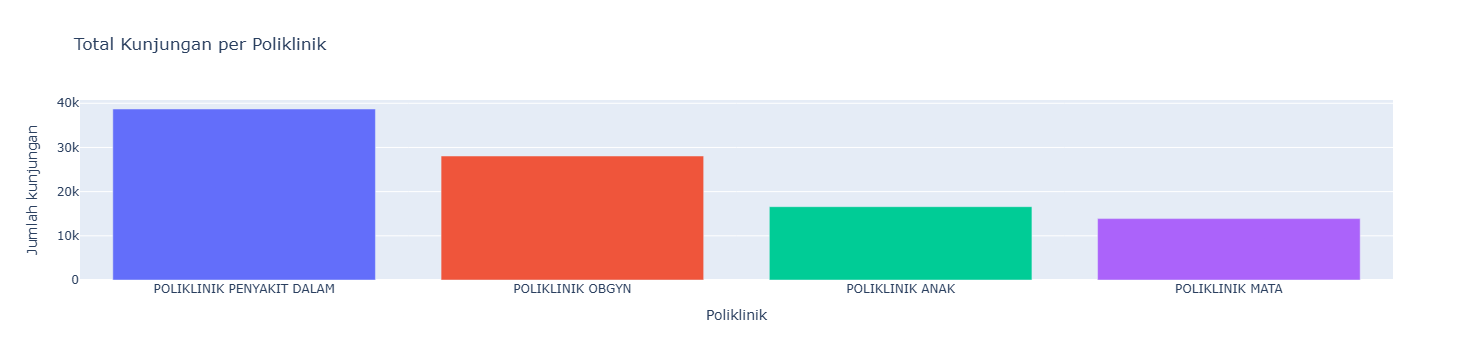

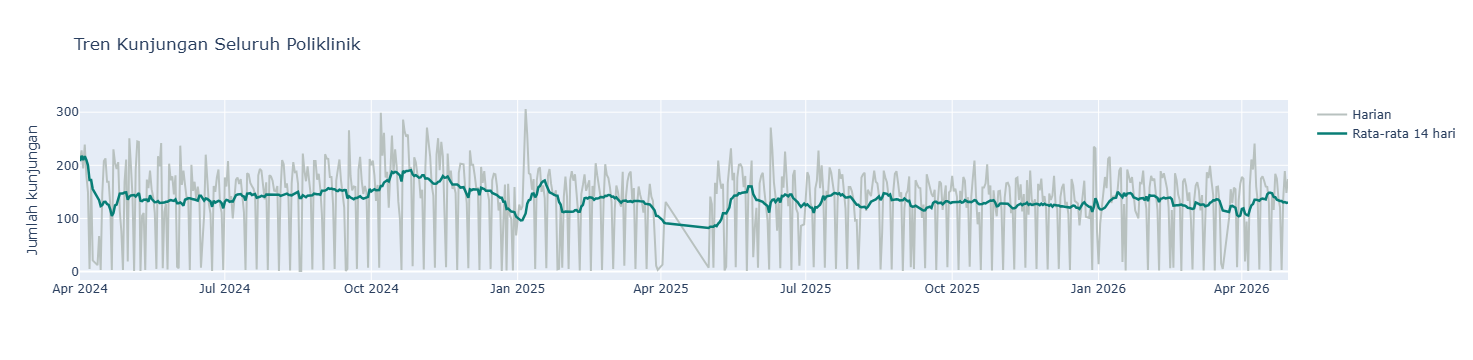

In [7]:
poli_totals = daily.groupby('poli', as_index=False)['y'].sum().sort_values('y', ascending=False)
fig = px.bar(
    poli_totals, x='poli', y='y', color='poli',
    title='Total Kunjungan per Poliklinik',
    labels={'poli': 'Poliklinik', 'y': 'Jumlah kunjungan'},
)
fig.update_layout(showlegend=False)
fig.show()

daily_total = daily.groupby('ds', as_index=False)['y'].sum().sort_values('ds')
daily_total['rata_rata_14_hari'] = daily_total['y'].rolling(14, min_periods=1).mean()
fig = go.Figure()
fig.add_scatter(x=daily_total['ds'], y=daily_total['y'], name='Harian', line={'color': '#B8C1BF'})
fig.add_scatter(
    x=daily_total['ds'], y=daily_total['rata_rata_14_hari'],
    name='Rata-rata 14 hari', line={'color': '#087E76', 'width': 2.5},
)
fig.update_layout(title='Tren Kunjungan Seluruh Poliklinik', yaxis_title='Jumlah kunjungan')
fig.show()

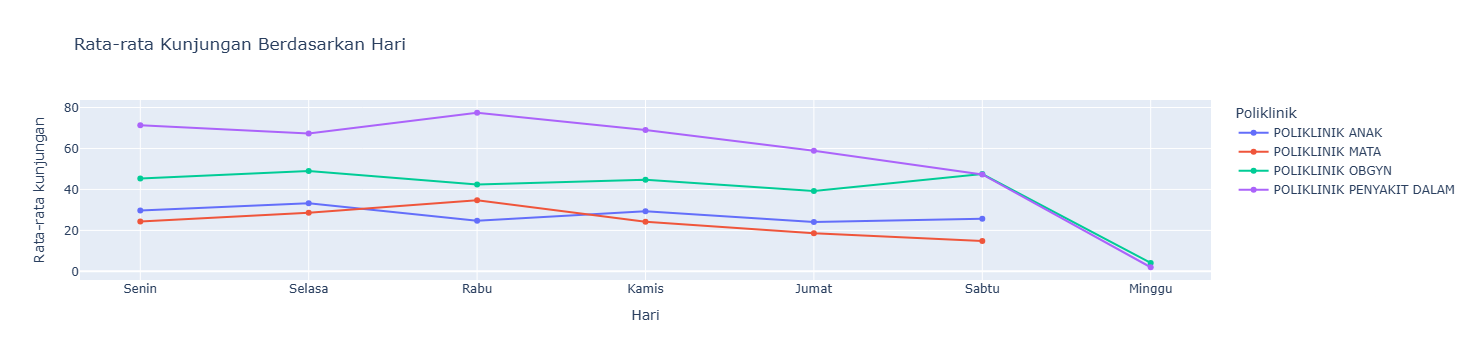

In [8]:
weekday_labels = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'}
weekday_pattern = daily.assign(weekday=daily['ds'].dt.weekday)
weekday_pattern = weekday_pattern.groupby(['poli', 'weekday'], as_index=False)['y'].mean()
weekday_pattern['hari'] = weekday_pattern['weekday'].map(weekday_labels)
fig = px.line(
    weekday_pattern, x='hari', y='y', color='poli', markers=True,
    category_orders={'hari': list(weekday_labels.values())},
    title='Rata-rata Kunjungan Berdasarkan Hari',
    labels={'hari': 'Hari', 'y': 'Rata-rata kunjungan', 'poli': 'Poliklinik'},
)
fig.show()

## Time-based train, validation, dan test split

Untuk setiap poli, 60 hari kalender terakhir menjadi test set. Enam puluh hari sebelum test menjadi validation set untuk memilih konfigurasi. Random split tidak digunakan.

In [9]:
splits = {}
split_summary = []
for poli, poli_data in daily.groupby('poli', sort=True):
    poli_data = poli_data[['ds', 'y']].sort_values('ds').reset_index(drop=True)
    test_cutoff = poli_data['ds'].max() - pd.Timedelta(days=TEST_HORIZON_DAYS)
    train_validation = poli_data[poli_data['ds'] <= test_cutoff].copy()
    test = poli_data[poli_data['ds'] > test_cutoff].copy()
    validation_cutoff = train_validation['ds'].max() - pd.Timedelta(days=TEST_HORIZON_DAYS)
    train = train_validation[train_validation['ds'] <= validation_cutoff].copy()
    validation = train_validation[train_validation['ds'] > validation_cutoff].copy()
    if len(train) < 60 or len(validation) < 7 or len(test) < 7:
        raise ValueError(f'Data {poli} tidak cukup untuk split berbasis waktu.')
    splits[poli] = {
        'all': poli_data, 'train': train, 'validation': validation,
        'train_validation': train_validation, 'test': test,
    }
    split_summary.append({
        'poli': poli,
        'train': f"{train.ds.min():%Y-%m-%d} s.d. {train.ds.max():%Y-%m-%d} ({len(train)})",
        'validation': f"{validation.ds.min():%Y-%m-%d} s.d. {validation.ds.max():%Y-%m-%d} ({len(validation)})",
        'test': f"{test.ds.min():%Y-%m-%d} s.d. {test.ds.max():%Y-%m-%d} ({len(test)})",
    })
display(pd.DataFrame(split_summary))

,poli,train,validation,test
0,POLIKLINIK ANAK,2024-04-01 s.d. 2025-12-30 (499),2025-12-31 s.d. 2026-02-28 (50),2026-03-02 s.d. 2026-04-30 (47)
1,POLIKLINIK MATA,2024-04-01 s.d. 2025-12-30 (475),2025-12-31 s.d. 2026-02-28 (47),2026-03-02 s.d. 2026-04-30 (46)
2,POLIKLINIK OBGYN,2024-04-01 s.d. 2025-12-31 (598),2026-01-01 s.d. 2026-03-01 (57),2026-03-02 s.d. 2026-04-30 (57)
3,POLIKLINIK PENYAKIT DALAM,2024-04-01 s.d. 2025-12-30 (501),2026-01-01 s.d. 2026-02-28 (49),2026-03-02 s.d. 2026-04-30 (47)


# 4. Modeling

Satu model Prophet dibangun untuk setiap poliklinik. Tuning membandingkan mode musiman dan fleksibilitas changepoint menggunakan MAE validation. Hari libur Indonesia ditambahkan pada seluruh kandidat.

In [10]:
tuning_rows = []
selected_configs = {}
for poli, split in splits.items():
    candidate_results = []
    for candidate_number, configuration in enumerate(PROPHET_TUNING_CANDIDATES, start=1):
        model = build_model(configuration).fit(split['train'], seed=RANDOM_SEED)
        prediction = model.predict(split['validation'][['ds']])['yhat'].clip(lower=0)
        metrics = calculate_metrics(split['validation']['y'], prediction)
        row = {
            'poli': poli, 'candidate': candidate_number,
            'seasonality_mode': configuration['seasonality_mode'],
            'changepoint_prior_scale': configuration['changepoint_prior_scale'],
            **metrics,
        }
        candidate_results.append((metrics['mae'], configuration))
        tuning_rows.append(row)
    best_mae, best_configuration = min(candidate_results, key=lambda item: item[0])
    selected_configs[poli] = best_configuration.copy()

tuning_results = pd.DataFrame(tuning_rows)
display(tuning_results.sort_values(['poli', 'mae']))

17:23:11 - cmdstanpy - INFO - Chain [1] start processing
17:23:11 - cmdstanpy - INFO - Chain [1] done processing
17:23:11 - cmdstanpy - INFO - Chain [1] start processing
17:23:11 - cmdstanpy - INFO - Chain [1] done processing
17:23:11 - cmdstanpy - INFO - Chain [1] start processing
17:23:12 - cmdstanpy - INFO - Chain [1] done processing
17:23:12 - cmdstanpy - INFO - Chain [1] start processing
17:23:12 - cmdstanpy - INFO - Chain [1] done processing
17:23:12 - cmdstanpy - INFO - Chain [1] start processing
17:23:12 - cmdstanpy - INFO - Chain [1] done processing
17:23:12 - cmdstanpy - INFO - Chain [1] start processing
17:23:12 - cmdstanpy - INFO - Chain [1] done processing
17:23:12 - cmdstanpy - INFO - Chain [1] start processing
17:23:12 - cmdstanpy - INFO - Chain [1] done processing
17:23:12 - cmdstanpy - INFO - Chain [1] start processing
17:23:13 - cmdstanpy - INFO - Chain [1] done processing
17:23:13 - cmdstanpy - INFO - Chain [1] start processing
17:23:13 - cmdstanpy - INFO - Chain [1]

,poli,candidate,seasonality_mode,changepoint_prior_scale,mae,rmse,wape,smape,bias
3,POLIKLINIK ANAK,4,multiplicative,0.05,5.11,6.89,21.36,23.60,0.89
2,POLIKLINIK ANAK,3,additive,0.10,5.19,6.95,21.69,23.98,0.57
0,POLIKLINIK ANAK,1,additive,0.05,5.20,6.99,21.75,23.97,0.89
1,POLIKLINIK ANAK,2,additive,0.01,5.36,7.10,22.42,24.76,-0.32
7,POLIKLINIK MATA,4,multiplicative,0.05,5.41,6.88,23.56,24.53,-0.15
6,POLIKLINIK MATA,3,additive,0.10,5.94,7.40,25.88,26.84,-0.07
4,POLIKLINIK MATA,1,additive,0.05,5.96,7.41,25.96,26.49,0.48
5,POLIKLINIK MATA,2,additive,0.01,6.01,7.46,26.17,26.23,1.27
9,POLIKLINIK OBGYN,2,additive,0.01,9.34,11.75,25.81,47.48,-4.69
8,POLIKLINIK OBGYN,1,additive,0.05,9.74,12.14,26.92,50.16,-5.57


In [11]:
selected_rows = []
for poli, configuration in selected_configs.items():
    selected = tuning_results[
        (tuning_results['poli'] == poli)
        & (tuning_results['seasonality_mode'] == configuration['seasonality_mode'])
        & (tuning_results['changepoint_prior_scale'] == configuration['changepoint_prior_scale'])
    ].sort_values('mae').iloc[0]
    selected_rows.append(selected)
display(pd.DataFrame(selected_rows)[
    ['poli', 'candidate', 'seasonality_mode', 'changepoint_prior_scale', 'mae', 'rmse', 'wape']
] )

,poli,candidate,seasonality_mode,changepoint_prior_scale,mae,rmse,wape
3,POLIKLINIK ANAK,4,multiplicative,0.05,5.11,6.89,21.36
7,POLIKLINIK MATA,4,multiplicative,0.05,5.41,6.88,23.56
9,POLIKLINIK OBGYN,2,additive,0.01,9.34,11.75,25.81
13,POLIKLINIK PENYAKIT DALAM,2,additive,0.01,16.68,21.62,25.08


# 5. Evaluation

Konfigurasi terpilih dilatih ulang dengan gabungan train dan validation, kemudian diuji satu kali pada test set. Baseline dihitung pada origin forecast yang sama.

In [12]:
metric_rows = []
test_prediction_frames = []
for poli, split in splits.items():
    test_model = build_model(selected_configs[poli]).fit(split['train_validation'], seed=RANDOM_SEED)
    prophet_prediction = test_model.predict(split['test'][['ds']])[
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ]
    prophet_prediction[['yhat', 'yhat_lower', 'yhat_upper']] = prophet_prediction[
        ['yhat', 'yhat_lower', 'yhat_upper']
    ].clip(lower=0)
    comparison = split['test'].merge(prophet_prediction, on='ds', how='inner')
    comparison['poli'] = poli
    test_prediction_frames.append(comparison)

    common = {
        'poli': poli,
        'test_start': split['test']['ds'].min().date().isoformat(),
        'test_end': split['test']['ds'].max().date().isoformat(),
        'n_test': len(split['test']),
    }
    metric_rows.append({
        **common, 'model': 'Prophet',
        **calculate_metrics(comparison['y'], comparison['yhat']),
    })
    baselines = create_baseline_forecasts(split['train_validation'], split['test']['ds'])
    for baseline_name, baseline_prediction in baselines.items():
        metric_rows.append({
            **common, 'model': baseline_name,
            **calculate_metrics(split['test']['y'], baseline_prediction),
        })

metrics_df = pd.DataFrame(metric_rows)
test_predictions = pd.concat(test_prediction_frames, ignore_index=True)
display(metrics_df.sort_values(['poli', 'mae']))

17:23:14 - cmdstanpy - INFO - Chain [1] start processing
17:23:14 - cmdstanpy - INFO - Chain [1] done processing
17:23:15 - cmdstanpy - INFO - Chain [1] start processing
17:23:15 - cmdstanpy - INFO - Chain [1] done processing
17:23:15 - cmdstanpy - INFO - Chain [1] start processing
17:23:15 - cmdstanpy - INFO - Chain [1] done processing
17:23:15 - cmdstanpy - INFO - Chain [1] start processing
17:23:15 - cmdstanpy - INFO - Chain [1] done processing


,poli,test_start,test_end,n_test,model,mae,rmse,wape,smape,bias
0,POLIKLINIK ANAK,2026-03-02,2026-04-30,47,Prophet,6.22,7.55,26.80,28.38,-1.59
4,POLIKLINIK ANAK,2026-03-02,2026-04-30,47,Moving Average 28,6.22,7.18,26.81,28.23,-0.03
3,POLIKLINIK ANAK,2026-03-02,2026-04-30,47,Moving Average 7,6.38,7.70,27.50,29.07,-2.78
1,POLIKLINIK ANAK,2026-03-02,2026-04-30,47,Naive,6.81,8.33,29.33,31.18,-4.21
2,POLIKLINIK ANAK,2026-03-02,2026-04-30,47,Seasonal Naive 7,7.28,8.91,31.35,34.18,-2.85
9,POLIKLINIK MATA,2026-03-02,2026-04-30,46,Moving Average 28,6.22,7.82,27.39,29.35,-0.32
8,POLIKLINIK MATA,2026-03-02,2026-04-30,46,Moving Average 7,6.63,8.27,29.19,31.44,-2.72
7,POLIKLINIK MATA,2026-03-02,2026-04-30,46,Seasonal Naive 7,6.78,8.45,29.86,31.85,-0.48
5,POLIKLINIK MATA,2026-03-02,2026-04-30,46,Prophet,9.08,10.83,39.98,47.65,-5.68
6,POLIKLINIK MATA,2026-03-02,2026-04-30,46,Naive,13.02,14.93,57.32,73.72,-12.72


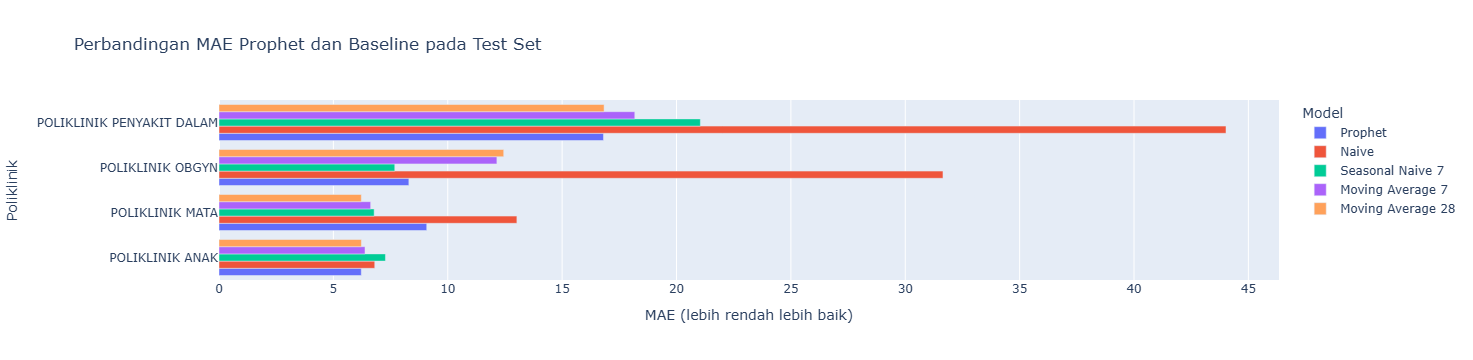

,poli,mae_prophet,baseline_terbaik,mae_baseline,prophet_unggul
0,POLIKLINIK ANAK,6.22,Moving Average 28,6.22,True
1,POLIKLINIK MATA,9.08,Moving Average 28,6.22,False
2,POLIKLINIK OBGYN,8.30,Seasonal Naive 7,7.68,False
3,POLIKLINIK PENYAKIT DALAM,16.81,Moving Average 28,16.83,True


In [13]:
fig = px.bar(
    metrics_df, x='mae', y='poli', color='model', barmode='group',
    title='Perbandingan MAE Prophet dan Baseline pada Test Set',
    labels={'mae': 'MAE (lebih rendah lebih baik)', 'poli': 'Poliklinik', 'model': 'Model'},
)
fig.show()

evaluation_summary = []
for poli, group in metrics_df.groupby('poli'):
    prophet_row = group[group['model'] == 'Prophet'].iloc[0]
    best_baseline = group[group['model'] != 'Prophet'].sort_values('mae').iloc[0]
    evaluation_summary.append({
        'poli': poli,
        'mae_prophet': prophet_row['mae'],
        'baseline_terbaik': best_baseline['model'],
        'mae_baseline': best_baseline['mae'],
        'prophet_unggul': bool(prophet_row['mae'] <= best_baseline['mae']),
    })
evaluation_summary = pd.DataFrame(evaluation_summary)
display(evaluation_summary)

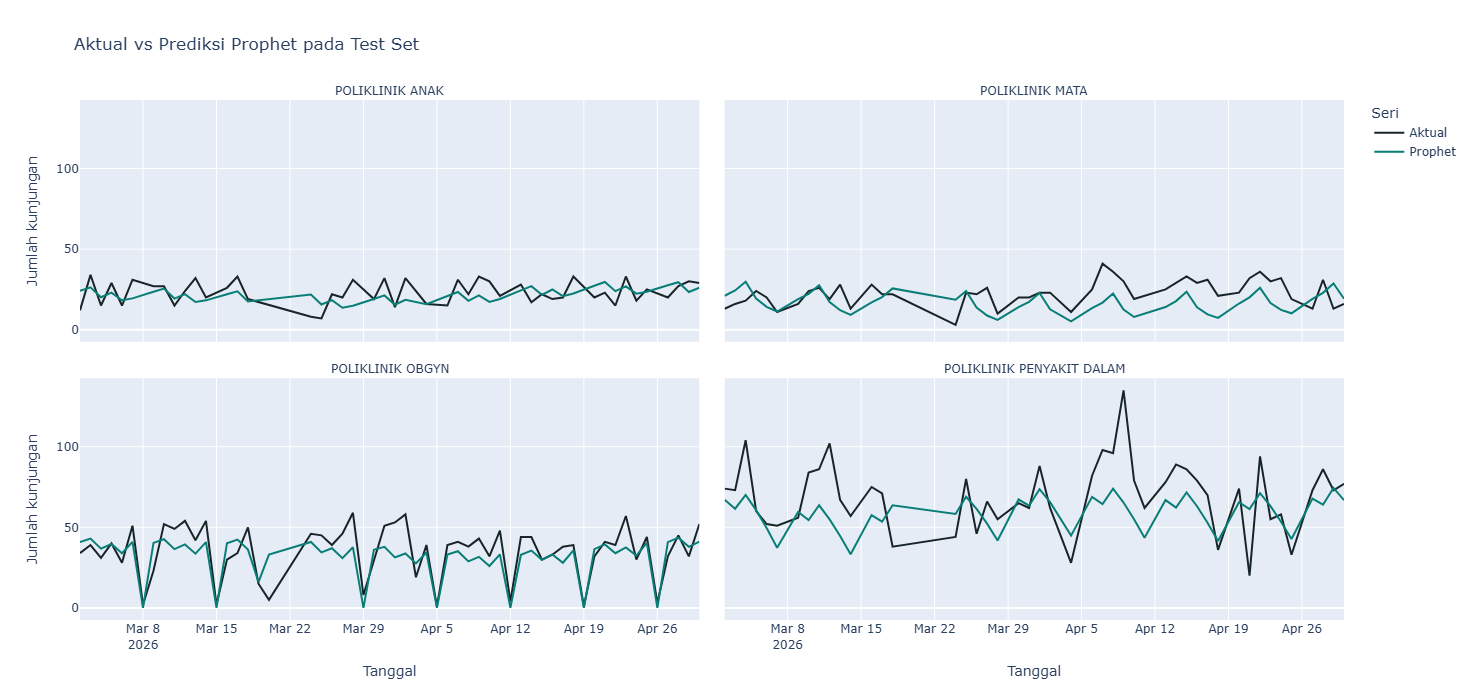

In [14]:
plot_data = test_predictions.melt(
    id_vars=['ds', 'poli'], value_vars=['y', 'yhat'],
    var_name='seri', value_name='jumlah',
)
plot_data['seri'] = plot_data['seri'].map({'y': 'Aktual', 'yhat': 'Prophet'})
fig = px.line(
    plot_data, x='ds', y='jumlah', color='seri', facet_col='poli', facet_col_wrap=2,
    title='Aktual vs Prediksi Prophet pada Test Set',
    labels={'ds': 'Tanggal', 'jumlah': 'Jumlah kunjungan', 'seri': 'Seri'},
    color_discrete_map={'Aktual': '#172529', 'Prophet': '#087E76'},
)
fig.update_layout(height=700)
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.show()

**Keputusan evaluasi:** status Prophet terhadap baseline harus dilaporkan apa adanya per poli. Model yang kalah dari baseline tetap dapat disimpan sesuai kebutuhan produk, tetapi aplikasi akan menampilkan peringatan dan hasilnya perlu dipantau saat data aktual baru tersedia.

# 6. Deployment

Setelah test selesai, model final dilatih menggunakan seluruh histori. Cell berikut menyimpan model, metadata, metrik test, dan prediksi test yang dibaca aplikasi Streamlit.

In [15]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
trained_at = datetime.now(ZoneInfo(APP_TIMEZONE)).isoformat(timespec='seconds')
metadata = {
    'trained_at': trained_at,
    'algorithm': 'Prophet',
    'prophet_version': prophet.__version__,
    'python_version': platform.python_version(),
    'configuration': PROPHET_CONFIG,
    'country_holidays': 'ID',
    'test_horizon_days': TEST_HORIZON_DAYS,
    'random_seed': RANDOM_SEED,
    'models': {},
}

for poli, split in splits.items():
    final_model = build_model(selected_configs[poli]).fit(split['all'], seed=RANDOM_SEED)
    filename = model_filename(poli)
    joblib.dump(final_model, MODELS_DIR / filename, compress=3)

    group = metrics_df[metrics_df['poli'] == poli]
    prophet_metrics = group[group['model'] == 'Prophet'].iloc[0]
    best_baseline = group[group['model'] != 'Prophet'].sort_values('mae').iloc[0]
    validation_mae = tuning_results[tuning_results['poli'] == poli]['mae'].min()
    metadata['models'][poli] = {
        'file': filename,
        'data_start': split['all']['ds'].min().date().isoformat(),
        'data_end': split['all']['ds'].max().date().isoformat(),
        'observations': len(split['all']),
        'total_visits': int(split['all']['y'].sum()),
        'evaluation_cutoff': split['train_validation']['ds'].max().date().isoformat(),
        'validation_mae': float(validation_mae),
        'selected_configuration': selected_configs[poli],
        'metrics': {
            key: float(prophet_metrics[key])
            for key in ['mae', 'rmse', 'wape', 'smape', 'bias']
        },
        'best_baseline': best_baseline['model'],
        'best_baseline_mae': float(best_baseline['mae']),
        'prophet_beats_baseline': bool(prophet_metrics['mae'] <= best_baseline['mae']),
    }

metrics_df.to_csv(METRICS_PATH, index=False)
test_predictions.to_csv(EVALUATION_PREDICTIONS_PATH, index=False, date_format='%Y-%m-%d')
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f"{len(metadata['models'])} model disimpan di {MODELS_DIR.relative_to(PROJECT_ROOT)}")

17:23:15 - cmdstanpy - INFO - Chain [1] start processing
17:23:15 - cmdstanpy - INFO - Chain [1] done processing
17:23:16 - cmdstanpy - INFO - Chain [1] start processing
17:23:16 - cmdstanpy - INFO - Chain [1] done processing
17:23:16 - cmdstanpy - INFO - Chain [1] start processing
17:23:16 - cmdstanpy - INFO - Chain [1] done processing
17:23:16 - cmdstanpy - INFO - Chain [1] start processing
17:23:16 - cmdstanpy - INFO - Chain [1] done processing


4 model disimpan di models


In [16]:
sanity_rows = []
for poli, info in metadata['models'].items():
    model = joblib.load(MODELS_DIR / info['file'])
    start = pd.Timestamp(info['data_end']) + pd.Timedelta(days=1)
    end = start + pd.Timedelta(days=29)
    forecast = make_daily_forecast(model, start, end, poli)
    sanity_rows.append({
        'poli': poli, 'jumlah_hari': len(forecast),
        'prediksi_minimum': forecast['yhat'].min(),
        'prediksi_maksimum': forecast['yhat'].max(),
        'semua_nonnegatif': bool((forecast[['yhat', 'yhat_lower', 'yhat_upper']] >= 0).all().all()),
    })
sanity_check = pd.DataFrame(sanity_rows)
display(sanity_check)
assert (sanity_check['jumlah_hari'] == 30).all()
assert sanity_check['semua_nonnegatif'].all()

,poli,jumlah_hari,prediksi_minimum,prediksi_maksimum,semua_nonnegatif
0,POLIKLINIK ANAK,30,0.00,33.42,True
1,POLIKLINIK MATA,30,0.00,31.40,True
2,POLIKLINIK OBGYN,30,0.00,46.05,True
3,POLIKLINIK PENYAKIT DALAM,30,0.00,84.30,True


## Operasional dan monitoring

- Jalankan aplikasi dengan `python -m streamlit run app.py`.
- Lakukan retraining setiap bulan, ketika data baru tersedia, atau ketika jadwal poli berubah.
- Pantau MAE dan bias per poli terhadap data aktual baru.
- Tinjau kembali model apabila baseline konsisten lebih baik atau terjadi perubahan pola layanan.
- Jangan memasukkan `dataset.xlsx` ke version control karena mengandung identitas pasien.